In [1]:
import pymc as pm
import numpy as np

from IPython.core.pylabtools import figsize
import matplotlib.pyplot as plt
import scipy.stats as stats
import arviz as az

plt.style.use("ggplot")
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)

In [2]:
# generate data ("observed")
mu = 0
sigma = 1
lam = 0.5
alpha = 0.5
beta = 3
# obs = stats.norm.rvs(loc=mu, scale=sigma, size=100)
# obs = stats.expon.rvs(lam, size=100)
obs = stats.beta.rvs(a=alpha, b=beta, size=100)

In [3]:
# model with observed data and posterior predictive check (ppc)

with pm.Model() as model:

    ## priors
    mu = pm.Uniform('mu', -5, 5) 
    sigma = pm.Uniform('sigma', .01, 3)
    lam = pm.Uniform('lam', .01, 3)
    alpha = pm.Uniform('alpha', .01, 3)
    beta = pm.Uniform('beta', .01, 5)

    ## observed data + distributional assumptions
    # observed = pm.Normal('observed', mu=mu, sigma=sigma, observed=obs)
    # observed = pm.Exponential('observed', lam=lam, observed=obs)
    observed = pm.Beta('observed', alpha=alpha, beta=beta, observed=obs)

    step = pm.Metropolis()
    trace = pm.sample(2000, step=step, chains=4)

    ## sample priors and posteriors for check
    prior = pm.sample_prior_predictive(samples=100)
    post = pm.sample_posterior_predictive(trace)


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [mu]
>Metropolis: [sigma]
>Metropolis: [lam]
>Metropolis: [alpha]
>Metropolis: [beta]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.
Sampling: [alpha, beta, lam, mu, observed, sigma]
Sampling: [observed]


Output()

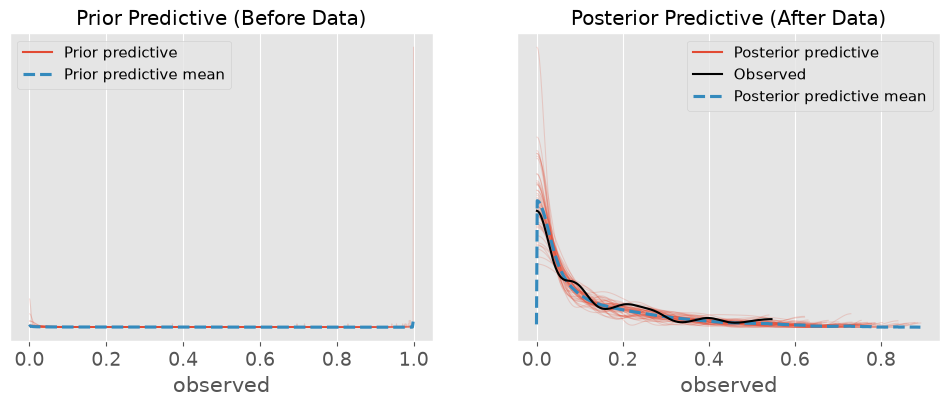

In [4]:
# compare prior and posterior sample distributions 

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
az.plot_ppc(prior, group="prior", num_pp_samples=50, ax=ax[0])
az.plot_ppc(post, group="posterior", num_pp_samples=50, ax=ax[1])
ax[0].set_title("Prior Predictive (Before Data)")
ax[1].set_title("Posterior Predictive (After Data)")
plt.show()